In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df=pd.read_csv("C:\\Users\\vishe\\Downloads\\Assignment\\outputs\\ons_panel_lad_2014_2025.csv")

In [2]:
df.head()

,year,region_code,region_name,area_type,industry_group,sic_codes,enterprises
0,2014,E07000004,Aylesbury Vale,LAD,"Agriculture, forestry & fishing",01-03,670
1,2014,E07000004,Aylesbury Vale,LAD,Production,05-39,495
2,2014,E07000004,Aylesbury Vale,LAD,Construction,41-43,1010
3,2014,E07000004,Aylesbury Vale,LAD,Motor trades,45,275
4,2014,E07000004,Aylesbury Vale,LAD,Wholesale,46,410


Understand Region Classification across Years

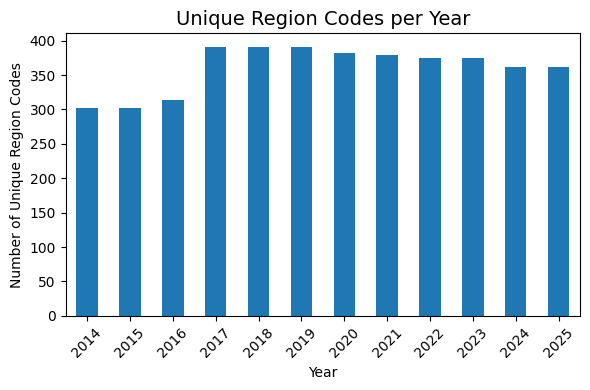

In [7]:
import matplotlib.pyplot as plt

unique_regions_per_year = df.groupby('year')['region_code'].nunique()

fig, ax = plt.subplots(figsize=(6, 4))
unique_regions_per_year.plot(kind='bar')
ax.set_title('Unique Region Codes per Year', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Unique Region Codes')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Share of Industry Groups in 2025

In [12]:
df_2025=df[df['year']==2025]
sum_df_2025=df_2025.groupby('industry_group')['enterprises'].sum()
sum_df_2025

industry_group
Accommodation & food services                       176690
Agriculture, forestry & fishing                     140835
Arts, entertainment, recreation & other services    191955
Business administration & support services          222060
Construction                                        384830
Education                                            49090
Finance & insurance                                  56490
Health                                              117235
Information & communication                         187695
Motor trades                                         82860
Production                                          147035
Professional, scientific & technical                419565
Property                                            122310
Public administration & defence                       7960
Retail                                              212900
Transport & Storage (inc. postal)                   114385
Wholesale                                

In [13]:
# Restrict to LADs present in every year - the balanced panel
balanced = (df.groupby("region_code")["year"].nunique() == 12)
panel = df[df["region_code"].isin(balanced[balanced].index)]

# Compute year-on-year growth rates by LAD x sector
panel = panel.sort_values(["region_code", "sic_codes", "year"])
panel["growth"] = panel.groupby(["region_code", "sic_codes"])["enterprises"].pct_change()

# For each LAD x sector: mean growth and standard deviation of growth
sector_stats = (
    panel.groupby(["region_code", "sic_codes"])["growth"]
         .agg(["mean", "std"])
         .reset_index()
)

In [14]:
sector_stats

,region_code,sic_codes,mean,std
0,E07000008,01-03,-0.029662,0.068694
1,E07000008,05-39,0.012391,0.053668
2,E07000008,41-43,0.013176,0.035961
3,E07000008,45,-0.014141,0.091898
4,E07000008,46,-0.010724,0.054251
...,...,...,...,...
4398,S12000045,77-82,0.033303,0.122056
4399,S12000045,84,NaN,NaN
4400,S12000045,85,0.042677,0.113599
4401,S12000045,86-88,0.033991,0.064104


Check data

In [ ]:
print(df.info())

print(df['enterprises'].describe())

zero_entries = df[df['enterprises'] == 0].shape[0]
print(f"Rows with 0 enterprises: {zero_entries}")

Understand Growth trends

In [ ]:
yearly_total = df.groupby('year')['enterprises'].sum()

plt.figure(figsize=(10, 5))
yearly_total.plot(kind='line', marker='o', color='teal', linewidth=2)
plt.title('Total UK Enterprises (LAD Level) 2014 - 2025', fontsize=14)
plt.ylabel('Total Enterprises')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()